23:13:52 - cmdstanpy - INFO - Chain [1] start processing
23:13:52 - cmdstanpy - INFO - Chain [1] done processing


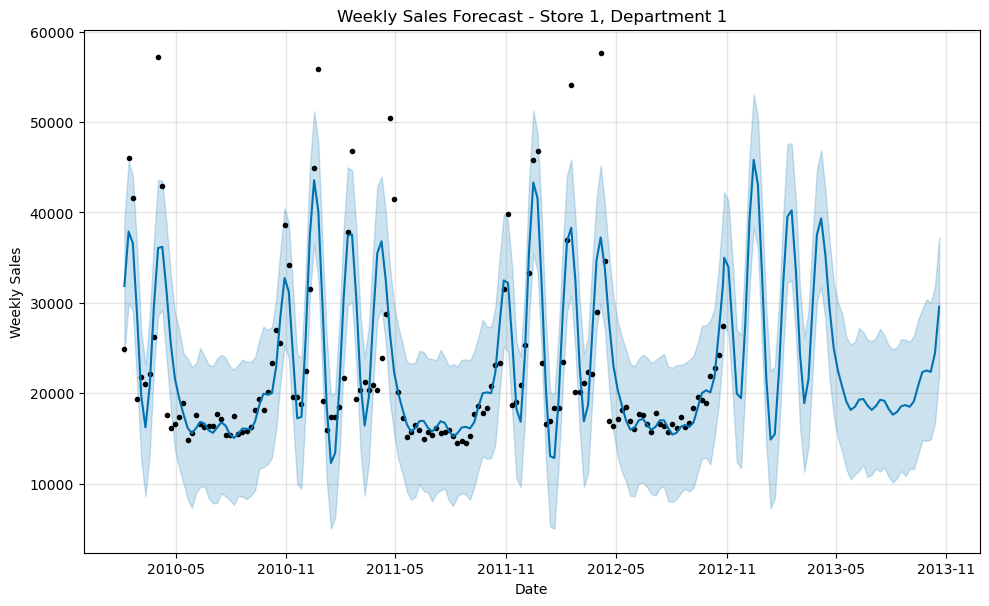

,ds,yhat,yhat_lower,yhat_upper
0,2010-02-05,31863.898745,24418.619796,39204.597587
1,2010-02-12,37885.253381,29916.657805,45629.564810
2,2010-02-19,36603.492337,29155.345905,44114.606795
3,2010-02-26,28713.464557,21231.412616,36218.680998
4,2010-03-05,19708.449036,12681.673126,26825.077041


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
import warnings
import os

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

# Ensure output directory exists
if not os.path.exists("data_clean"):
    os.makedirs("data_clean")

# Load cleaned Walmart data
df = pd.read_csv("data_clean/walmart_clean.csv", parse_dates=["Date"])

# Filter Store 1, Department 1
store_dept = (
    df[(df["Store"] == 1) & (df["Dept"] == 1)]
    .sort_values("Date")
    .reset_index(drop=True)
)

# Prepare data for Prophet
ts_data = store_dept[["Date", "Weekly_Sales"]].rename(
    columns={"Date": "ds", "Weekly_Sales": "y"}
)

# Initialize and train Prophet model
model = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)
model.fit(ts_data)

# Create future dates (52 weeks)
future = model.make_future_dataframe(periods=52, freq="W")

# Generate forecast
forecast = model.predict(future)

# Plot forecast
fig = model.plot(forecast)
plt.title("Weekly Sales Forecast - Store 1, Department 1")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.show()

# Save forecast for Power BI
forecast_output = forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]]
forecast_output.to_csv("data_clean/forecast_store1_dept1.csv", index=False)

forecast_output.head()